# 03 · ETL — Pose Estimation & Filtering

Estimate pitch, yaw, and roll with 6DRepNet. Faces outside the ISO/IEC 19794-5 biometric quality window are discarded.

In [1]:
import IPython.display as dp 
from sixdrepnet import SixDRepNet
import cv2
import glob
from PIL import Image
import numpy as np
from tqdm import tqdm
import os
import shutil
import pandas as pd

In [2]:
url = "https://developer.enablex.io/images/face-ai/facexpose1.png"
dp.display(dp.Image(url=url))

In [3]:
def get_pitch_yaw_roll(img_path, draw = False):
    
    model = SixDRepNet()
    
    img = cv2.imread(img_path)
    
    pitch, yaw, roll = model.predict(img)
    pitch = pitch[0]
    yaw = yaw[0]
    roll = roll[0]

    pitch = round(float(pitch),2)
    yaw = round(float(yaw),2)
    roll = round(float(roll),2)

    if draw:
        img_draw_axis = model.draw_axis(img, yaw, pitch, roll)
        img_pil = Image.fromarray(img_draw_axis.astype(np.uint8))
        img_pil.show()
    return abs(pitch), abs(yaw), abs(roll)

#### CELEBA

In [ ]:
celeba_folder_path = glob.glob('./CELEBA/curated/*')
progress_bar = tqdm(celeba_folder_path)
contador  = 0
results = []
for img_path in progress_bar:
    
    try:
        pitch, yaw, roll = get_pitch_yaw_roll(img_path, draw = False)
        file_name = os.path.basename(img_path)
        temp = {
            'dataset_name' : 'CELEBA',
            'file_name' : file_name,
            'pitch' : pitch,
            'yaw' : yaw,
            'roll' : roll,
        }
        results.append(temp)
        if pitch <= 7 and yaw <= 6 and roll <= 4:
            contador +=1
            shutil.copy(img_path,f'./CELEBA/cropped_and_aligned/{file_name}')
    except:
        pass
    progress_bar.set_postfix({'faces_aligned' : contador})
results_df = pd.DataFrame(results)
results_df.to_parquet('./CELEBA/metadata_dataset.parquet')

#### VGG Face

In [ ]:
vgg_folder_path = glob.glob('./VGG_FACE/curated/*')
progress_bar = tqdm(vgg_folder_path)
contador  = 0
results = []
for img_path in progress_bar:
    
    try:
        pitch, yaw, roll = get_pitch_yaw_roll(img_path, draw = False)
        file_name = os.path.basename(img_path)
        temp = {
            'dataset_name' : 'VGG_FACE',
            'file_name' : file_name,
            'pitch' : pitch,
            'yaw' : yaw,
            'roll' : roll,
        }
        results.append(temp)
        if pitch <= 7 and yaw <= 6 and roll <= 4:
            contador +=1
            shutil.copy(img_path,f'./VGG_FACE/cropped_and_aligned/{file_name}')
    except:
        pass
    progress_bar.set_postfix({'faces_aligned' : contador})
results_df = pd.DataFrame(results)
results_df.to_parquet('./VGG_FACE/vgg_face_metadata_dataset.parquet')

#### UTK FACE

In [7]:
utk_folder_path = glob.glob('./UTK_FACE/curated/*')
progress_bar = tqdm(utk_folder_path)
contador  = 0
results = []
for img_path in progress_bar:
    
    try:
        pitch, yaw, roll = get_pitch_yaw_roll(img_path, draw = False)
        file_name = os.path.basename(img_path)
        temp = {
            'dataset_name' : 'UTK_FACE',
            'file_name' : file_name,
            'pitch' : pitch,
            'yaw' : yaw,
            'roll' : roll,
        }
        results.append(temp)
        if pitch <= 7 and yaw <= 6 and roll <= 4:
            contador +=1
            shutil.copy(img_path,f'./UTK_FACE/cropped_and_aligned/{file_name}')
    except:
        pass
    progress_bar.set_postfix({'faces_aligned' : contador})
results_df = pd.DataFrame(results)
results_df.to_parquet('./UTK_FACE/utk_face_pose_estimation.parquet')

100%|██████████| 16824/16824 [1:39:54<00:00,  2.81it/s, faces_aligned=2788]


#### FLICKR

In [ ]:
flickr_folder_path = glob.glob('./FLICKR/curated/*')
progress_bar = tqdm(flickr_folder_path)
contador  = 0
results = []
for img_path in progress_bar:
    
    try:
        pitch, yaw, roll = get_pitch_yaw_roll(img_path, draw = False)
        file_name = os.path.basename(img_path)
        temp = {
            'dataset_name' : 'FLICKR',
            'file_name' : file_name,
            'pitch' : pitch,
            'yaw' : yaw,
            'roll' : roll,
        }
        results.append(temp)
        if pitch <= 7 and yaw <= 6 and roll <= 4:
            contador +=1
            shutil.copy(img_path,f'./FLICKR/cropped_and_aligned/{file_name}')
    except:
        pass
    progress_bar.set_postfix({'faces_aligned' : contador})
results_df = pd.DataFrame(results)
results_df.to_parquet('./FLICKR/flickr_pose_estimation.parquet')

In [45]:
flickr = pd.read_parquet('./FLICKR/flickr_pose_estimation.parquet')
celeba = pd.read_parquet('./CELEBA/celeba_pose_estimation.parquet')
utkface = pd.read_parquet('./UTK_FACE/utk_face_pose_estimation.parquet')
vgg = pd.read_parquet('./VGG_FACE/vgg_face_pose_estimation.parquet')

In [59]:
df = pd.concat([celeba,flickr,utkface,vgg])
frontal_face_criterium = (df['pitch'] <= 7) & (df['yaw'] <= 6) & (df['roll'] <= 4)
df = df[frontal_face_criterium]
df.head()

,dataset_name,file_name,pitch,yaw,roll
1,CELEBA,008826.jpg,2.32,5.35,3.62
8,CELEBA,052431.jpg,6.37,0.28,0.13
10,CELEBA,196664.jpg,1.73,2.10,0.32
11,CELEBA,178079.jpg,4.38,5.08,0.02
18,CELEBA,123068.jpg,4.65,3.91,0.33


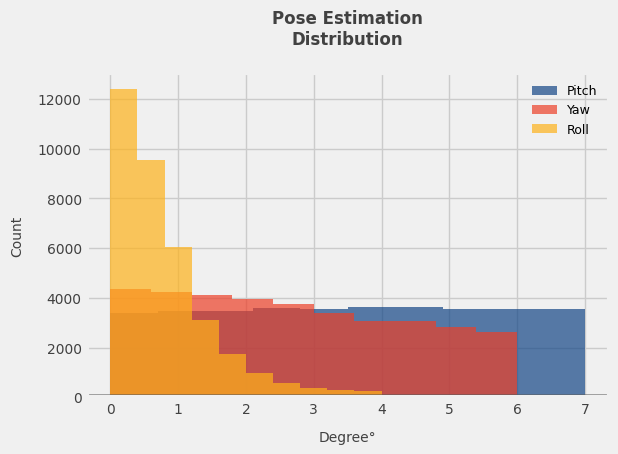

In [72]:
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

fig, ax = plt.subplots(figsize=(6,4))

# Histograma 1
ax.hist(
    df['pitch'],
    bins=10,
    color='#134686',
    alpha=0.7,
    lw=2,
    label='Pitch'
)

# Histograma 2
ax.hist(
    df['yaw'],
    bins=10,
    color='#ED3F27',
    alpha=0.7,
    lw=2,
    label='Yaw'
)

# Histograma 3
ax.hist(
    df['roll'],
    bins=10,
    color='#FEB21A',
    alpha=0.7,
    lw=2,
    label='Roll'
)

# Labels
ax.set_ylabel('Count', fontsize=10, color='#414141', labelpad=10)
ax.set_xlabel('Degree°', fontsize=10, color='#414141', labelpad=10)

# Línea horizontal en y=0
ax.axhline(y=0, color='#414141', linewidth=5, alpha=.5)

# Ticks
ax.tick_params(axis='y', labelsize=10, colors='#414141')
ax.tick_params(axis='x', labelsize=10, colors='#414141')

# Título
ax.set_title(
    'Pose Estimation\nDistribution\n',
    fontsize=12,
    color='#414141',
    fontweight='bold'
)
ax.legend(
    fontsize=9,
    frameon=False
)
fig.savefig('./figures/pose_estimation_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


In [73]:
df = pd.concat([celeba,flickr,utkface,vgg])
df.head()

,dataset_name,file_name,pitch,yaw,roll
0,CELEBA,150845.jpg,0.75,21.35,2.59
1,CELEBA,008826.jpg,2.32,5.35,3.62
2,CELEBA,170304.jpg,13.23,4.53,1.70
3,CELEBA,065966.jpg,6.73,20.78,2.99
4,CELEBA,164752.jpg,13.84,0.80,0.74


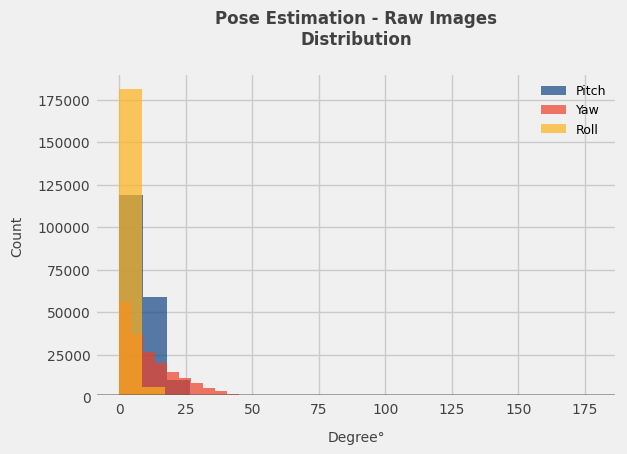

In [83]:
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

fig, ax = plt.subplots(figsize=(6,4))

# Histograma 1
ax.hist(
    df['pitch'],
    bins=20,
    color='#134686',
    alpha=0.7,
    lw=2,
    label='Pitch',
)

# Histograma 2
ax.hist(
    df['yaw'],
    bins=20,
    color='#ED3F27',
    alpha=0.7,
    lw=2,
    label='Yaw',
)

# Histograma 3
ax.hist(
    df['roll'],
    bins=20,
    color='#FEB21A',
    alpha=0.7,
    lw=2,
    label='Roll',
)

# Labels
ax.set_ylabel('Count', fontsize=10, color='#414141', labelpad=10)
ax.set_xlabel('Degree°', fontsize=10, color='#414141', labelpad=10)

# Línea horizontal en y=0
ax.axhline(y=0, color='#414141', linewidth=5, alpha=.5)

# Ticks
ax.tick_params(axis='y', labelsize=10, colors='#414141')
ax.tick_params(axis='x', labelsize=10, colors='#414141')

# Título
ax.set_title(
    'Pose Estimation - Raw Images\nDistribution\n',
    fontsize=12,
    color='#414141',
    fontweight='bold'
)
ax.legend(
    fontsize=9,
    frameon=False
)
fig.savefig('./figures/pose_estimation_distribution_raw_dataset.png', dpi=300, bbox_inches='tight')
plt.show()
